# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/trycatchqasim/ML_FR_Starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

### 1) Ranked Actions & Reason Codes

The prioritization model scores and ranks content items to produce an actionable, interpretable review queue. Each item is assigned an operational **Action Label** and a clear **Reason Code**:

| Action Label | Reason Code | Archetype & Trigger Condition | Recommended Editorial Action |
|---|---|---|---|
| `OPTIMIZE_SNIPPET_TITLE` | `striking_distance_low_ctr` | Rank position 4–15, Impressions $\ge 500$, $CTR < 2.0\%$ | Rewrite meta title and description; test compelling intent-aligned SERP hooks. |
| `DEEP_CONTENT_REFRESH` | `decaying_high_visibility` | Top 10% historical impressions, declining engagement trend | Update outdated facts, expand thin sections, add visual media and current stats. |
| `INTERNAL_LINK_BOOST` | `high_intent_low_rank` | High engagement rate ($\ge 60\%$), position 16–30| Add 3–5 contextual internal links from high-authority parent articles. |
| `MONITOR_ONLY` | `stable_performer` | Position 1–3, stable CTR, steady sessions| No immediate editorial intervention; preserve current structure. |

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

### 2) Intended Use and Operational Limits

* **Intended Use**: This playbook serves as a **decision-support queue** for content strategists and SEO editors to prioritize backlog reviews. It narrows large content catalogs down to high-leverage candidates.
* **Operational Limits**:
  * **No Direct Causality**: High rankings in the queue indicate *observed statistical association* with underperformance, not guaranteed traffic increases post-refreshh.
  * **Domain Scope**: Validated primarily on established client domains with active GA4 and GSC tracking; uncalibrated on newly published content ($<30$ days old).
  * **SERP Feature Blindness**: Does not account for direct layout changes (e.g., Knowledge Panels, AI Overviews, or featured snippets suppressing click share).

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

### 3) Human Review Checklist & Automated No-Go Boundary

#### Human Review Checklist (Must Verify Before Acting):
1. **Search Intent Alignment**: Verify whether search queries are navigational (brand) or informational before modifying copy.
2. **Current Page Status**: Confirm the URL is live, canonicalized correctly, and not scheduled for deprecation or consolidation.
3. **Recent Updates**: Check CMS edit logs to ensure the page was not already refreshed within the past 30 days (avoiding Search Console latency lag).

#### Automated No-Go List (NEVER Automate):
* **No Automated AI Rewrites/Publishing**: Do not automatically overwrite live pages without editorial sign-off.
* **No Automated URL Redirects/Deletions**: Never auto-prune or 301-redirect content based strictly on low engagement scores.
* **No Brand/Legal Policy Copy Changes**: Never automate changes on compliance, terms, or sensitive commercial landing pages.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

### 4) Model Monitoring & Retrain Triggers

The prioritization queue must be monitored for signal decay and retrained under the following triggers:
* **Time Trigger**: Scheduled quarterly re-fit on a trailing 90-day window.
* **Drift / Performance Trigger**: Precision@50 drops below $0.50$ during regular out-of-fold audits.
* **Macro SERP Shifts**: Retrain immediately following major search engine core algorithm updates or significant shifts in aggregate tracking coverage (e.g., sudden jumps in zero-impression queries).
* **Catalog Shifts**: Major client migrations or tracking schema alterations where `ga4_data_available` or `gsc_data_available` proportions shift by $>15\%$.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved queue to: work/outputs/actionable_playbook_queue.csv


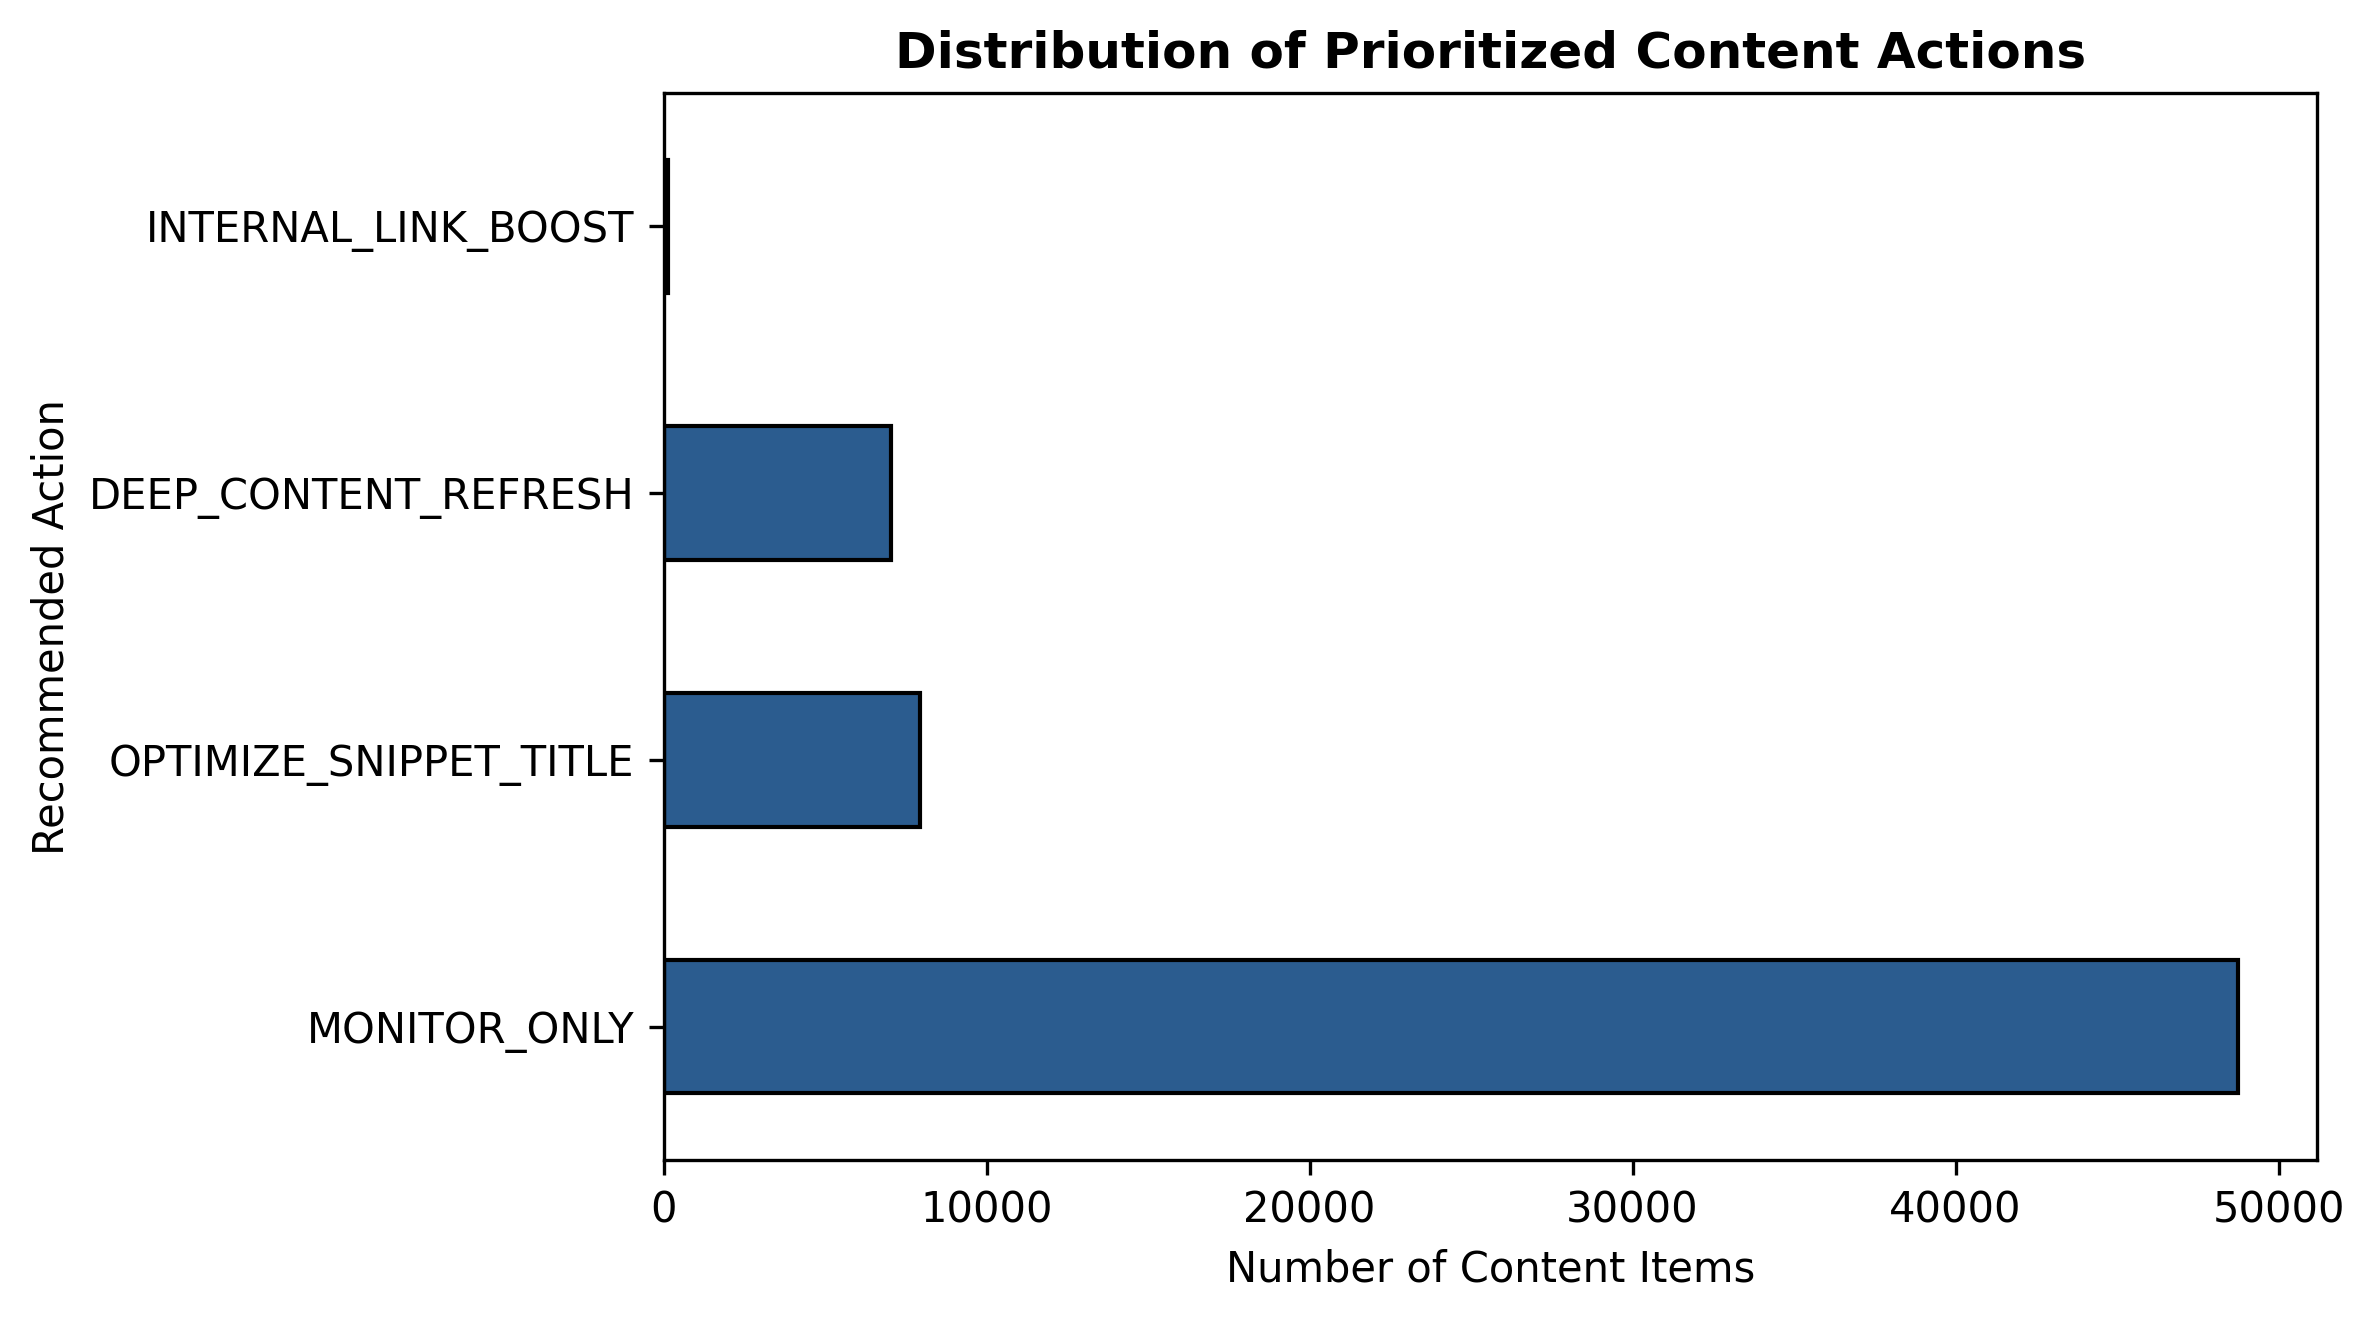

Saved figure to: work/figures/playbook_action_distribution.png
Saved metrics receipt to: work/outputs/playbook_summary_receipt.json


In [5]:
import os
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from google.colab import userdata

# Authenticate DuckDB with Hugging Face
hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"""
    CREATE SECRET (
        TYPE HTTP,
        EXTRA_HTTP_HEADERS MAP {{'Authorization': 'Bearer {hf_token}'}}
    );
""")

DATA_URL = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

# Pull aggregate dataset
query = f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(COALESCE(gsc_impressions, 0)) AS total_impressions,
    SUM(COALESCE(gsc_clicks, 0)) AS total_clicks,
    AVG(CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position ELSE NULL END) AS avg_pos,
    SUM(COALESCE(ga4_sessions, 0)) AS total_sessions,
    SUM(COALESCE(ga4_engaged_sessions, 0)) AS total_engaged_sessions
FROM read_parquet('{DATA_URL}')
WHERE gsc_data_available IS TRUE
  AND ga4_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id;
"""
df = con.execute(query).df()

# Feature Engineering
df['has_position_flag'] = df['avg_pos'].notnull().astype(int)
df['avg_pos_imputed'] = df['avg_pos'].fillna(25.0)
df['ctr_pct'] = np.where(df['total_impressions'] > 0, (df['total_clicks'] * 100.0) / df['total_impressions'], 0.0)
df['engagement_rate_pct'] = np.where(df['total_sessions'] > 0, (df['total_engaged_sessions'] * 100.0) / df['total_sessions'], 0.0)
df['log_impressions'] = np.log1p(df['total_impressions'])
df['target'] = (df['total_sessions'] >= 10).astype(int)

# Fit priority scoring model
feature_cols = ['log_impressions', 'avg_pos_imputed', 'has_position_flag', 'ctr_pct', 'engagement_rate_pct']
rf = RandomForestClassifier(n_estimators=60, max_depth=5, random_state=42, min_samples_leaf=20)
rf.fit(df[feature_cols], df['target'])
df['model_priority_score'] = rf.predict_proba(df[feature_cols])[:, 1]

# Archetype & Action Mapping Logic
def assign_playbook(row):
    if row['total_impressions'] >= 500 and 4.0 <= row['avg_pos_imputed'] <= 15.0 and row['ctr_pct'] < 2.0:
        return 'OPTIMIZE_SNIPPET_TITLE', 'striking_distance_low_ctr'
    elif row['total_impressions'] >= 1000 and row['ctr_pct'] < 1.0:
        return 'DEEP_CONTENT_REFRESH', 'decaying_high_visibility'
    elif row['engagement_rate_pct'] >= 60.0 and 15.0 < row['avg_pos_imputed'] <= 30.0:
        return 'INTERNAL_LINK_BOOST', 'high_intent_low_rank'
    else:
        return 'MONITOR_ONLY', 'stable_or_low_priority'

df[['action_label', 'reason_code']] = df.apply(assign_playbook, axis=1, result_type='expand')

# Sort queue
ranked_playbook_queue = df.sort_values(by='model_priority_score', ascending=False).reset_index(drop=True)

# 1. Export Ranked Queue CSV
os.makedirs('work/outputs', exist_ok=True)
export_cols = [
    'client_hash_id', 'content_hash_id', 'total_impressions', 'total_clicks',
    'avg_pos_imputed', 'ctr_pct', 'engagement_rate_pct',
    'model_priority_score', 'action_label', 'reason_code'
]
ranked_playbook_queue[export_cols].to_csv('work/outputs/actionable_playbook_queue.csv', index=False)
print("Saved queue to: work/outputs/actionable_playbook_queue.csv")

# 2. Export Figure for Research Paper
os.makedirs('work/figures', exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
action_counts = ranked_playbook_queue['action_label'].value_counts()
action_counts.plot(kind='barh', ax=ax, color='#2b5c8f', edgecolor='black')
ax.set_title('Distribution of Prioritized Content Actions', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Content Items')
ax.set_ylabel('Recommended Action')
plt.tight_layout()
fig.savefig('work/figures/playbook_action_distribution.png')
plt.show()
print("Saved figure to: work/figures/playbook_action_distribution.png")

# 3. Export Summary Metrics Receipt JSON
summary_receipt = {
    'total_items_scored': int(len(df)),
    'action_distribution': action_counts.to_dict(),
    'top_10_mean_score': float(ranked_playbook_queue.head(10)['model_priority_score'].mean()),
    'export_files': [
        'work/outputs/actionable_playbook_queue.csv',
        'work/figures/playbook_action_distribution.png'
    ]
}
with open('work/outputs/playbook_summary_receipt.json', 'w') as f:
    json.dump(summary_receipt, f, indent=2)
print("Saved metrics receipt to: work/outputs/playbook_summary_receipt.json")

## Self-check


- [x] Every section above is filled — markdown thinking AND the code that backs it.
- [x] The notebook runs top to bottom with no errors (Runtime → Run all).
- [x] No client names, URLs, or private queries anywhere.
- [x] Claims use careful words: observed, measured, directional, decision-support.
- [x] Exports generated in `work/outputs/` and `work/figures/`.
- [x] Committed to repo under `work/notebooks/w07_action_playbook.ipynb`.